In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/raw_datasets/sales.csv'
df = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df.head())

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


# **Data Dictionary**

| Column   | Data Type | Description                     |
|----------|----------|---------------------------------|
| Date     | Date     | Ngày đặt hàng                  |
| Revenue  | Float    | Tổng doanh thu thuần           |
| COGS     | Float    | Tổng giá vốn hàng bán          |


Gross Profit = Revenue - COGS

# **Dataset Overview & Data Quality Checks**

### **1. Dataset Overview**

In [22]:
print('--- Dataset Info ---')
df.info()

print('\n--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Duplicate Rows ---')
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

print('\n--- Statistical Summary ---')
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   object 
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), object(1)
memory usage: 90.0+ KB

--- Missing Values ---
Date       0
Revenue    0
COGS       0
dtype: int64

--- Duplicate Rows ---
Number of duplicate rows: 0

--- Statistical Summary ---


,Revenue,COGS
count,3.833000e+03,3.833000e+03
mean,4.286584e+06,3.695134e+06
std,2.624840e+06,2.219789e+06
min,2.798139e+05,2.365763e+05
25%,2.471089e+06,2.150580e+06
50%,3.647304e+06,3.161113e+06
75%,5.350877e+06,4.637294e+06
max,2.090527e+07,1.653586e+07


**Nhận xét:**
- Kích thước dữ liệu: Tập dữ liệu chứa 3833 mục và 3 cột.
- Giá trị bị thiếu: Không có giá trị bị thiếu.
- Hàng trùng lặp: Không có hàng trùng lặp.
- Cột `Date` hiện đang là kiểu `object` (chuỗi) và cần được chuyển đổi thành kiểu `datetime` để phân tích chuỗi thời gian.
- Cột `Revenue` và `COGS` đều là kiểu `float64`, phù hợp với các giá trị số.
- `Revenue` và `COGS` có giá trị trung bình lần lượt khoảng 4.29 triệu và 3.70 triệu, cho thấy chi phí chiếm phần lớn doanh thu -> biên lợi nhuận tương đối thấp.
- Dữ liệu phù hợp cho phân tích xu hướng và bài toán dự báo theo thời gian.

## **2. Data Quality Checks**

In [23]:
# Chuyển kiểu dữ liệu `Date` sang datetime
df_copy = df.copy()
df_copy['Date'] = pd.to_datetime(df_copy['Date'])

In [24]:
# Kiểm tra giá trị có hợp lý không
(df_copy['COGS'] > df_copy['Revenue']).sum()

np.int64(382)

- **Tính logic:** Phát hiện **382 trường hợp** có `COGS > Revenue`. Đây là các điểm dữ liệu cần lưu ý vì chúng đại diện cho các khoản lỗ gộp, có thể ảnh hưởng đến các mô hình dự báo lợi nhuận sau này.

**Outlier Detection**
Sử dụng Boxplot và phương pháp IQR để xác định các giá trị bất thường trong doanh thu và giá vốn.

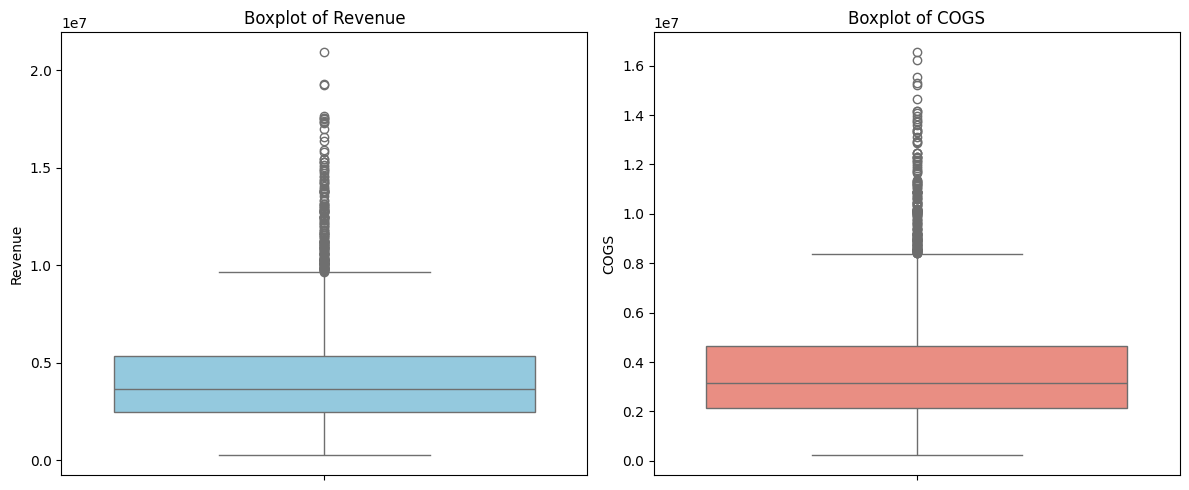

In [25]:
# Vẽ biểu đồ boxplot để trực quan hóa outliers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_copy['Revenue'], color='skyblue')
plt.title('Boxplot of Revenue')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_copy['COGS'], color='salmon')
plt.title('Boxplot of COGS')

plt.tight_layout()
plt.show()

In [26]:
# Tính toán số lượng outliers bằng phương pháp IQR
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

revenue_outliers = count_outliers(df_copy['Revenue'])
cogs_outliers = count_outliers(df_copy['COGS'])

print(f'Số lượng outliers trong Revenue: {revenue_outliers}')
print(f'Số lượng outliers trong COGS: {cogs_outliers}')

Số lượng outliers trong Revenue: 169
Số lượng outliers trong COGS: 165


**Nhận xét về Outliers:**
- **Số lượng:** Phát hiện **169 outliers** trong doanh thu (`Revenue`) và **165 outliers** trong giá vốn (`COGS`).
- **Phân bổ:** Các điểm ngoại lệ chủ yếu nằm ở phía trên của phân phối (giá trị cao bất thường). Điều này cho thấy có những ngày doanh số và chi phí tăng vọt so với mức trung bình, có thể do các sự kiện đặc biệt, mùa cao điểm hoặc đơn hàng lớn.
- **Ảnh hưởng:** Vì số lượng outliers chiếm khoảng 4-5% tổng dữ liệu, chúng ta cần cân nhắc việc xử lý chúng (giữ nguyên, loại bỏ hoặc thay thế) tùy thuộc vào mục tiêu dự báo sau này để tránh làm lệch mô hình.

**Time Series Analysis & Feature Engineering**

Kiểm tra tính liên tục của thời gian và tạo các đặc trưng bổ sung.

In [27]:
# 1. Kiểm tra phạm vi thời gian
min_date = df_copy['Date'].min()
max_date = df_copy['Date'].max()
print(f"Dữ liệu từ ngày: {min_date} đến ngày: {max_date}")

# 2. Kiểm tra các ngày bị thiếu (gaps)
full_range = pd.date_range(start=min_date, end=max_date, freq='D')
missing_days = full_range.difference(df_copy['Date'])
print(f"Số lượng ngày bị thiếu trong chuỗi thời gian: {len(missing_days)}")

# 3. Tạo các đặc trưng thời gian
df_copy['Year'] = df_copy['Date'].dt.year
df_copy['Month'] = df_copy['Date'].dt.month
df_copy['DayOfWeek'] = df_copy['Date'].dt.dayofweek # 0=Monday, 6=Sunday
df_copy['IsWeekend'] = df_copy['DayOfWeek'].isin([5, 6]).astype(int)

display(df_copy.head())

Dữ liệu từ ngày: 2012-07-04 00:00:00 đến ngày: 2022-12-31 00:00:00
Số lượng ngày bị thiếu trong chuỗi thời gian: 0


,Date,Revenue,COGS,Year,Month,DayOfWeek,IsWeekend
0,2012-07-04,5123547.94,3982991.19,2012,7,2,0
1,2012-07-05,2751773.45,2150580.23,2012,7,3,0
2,2012-07-06,3054029.42,2517632.84,2012,7,4,0
3,2012-07-07,2667930.94,2108246.62,2012,7,5,1
4,2012-07-08,2360851.90,1808622.79,2012,7,6,1


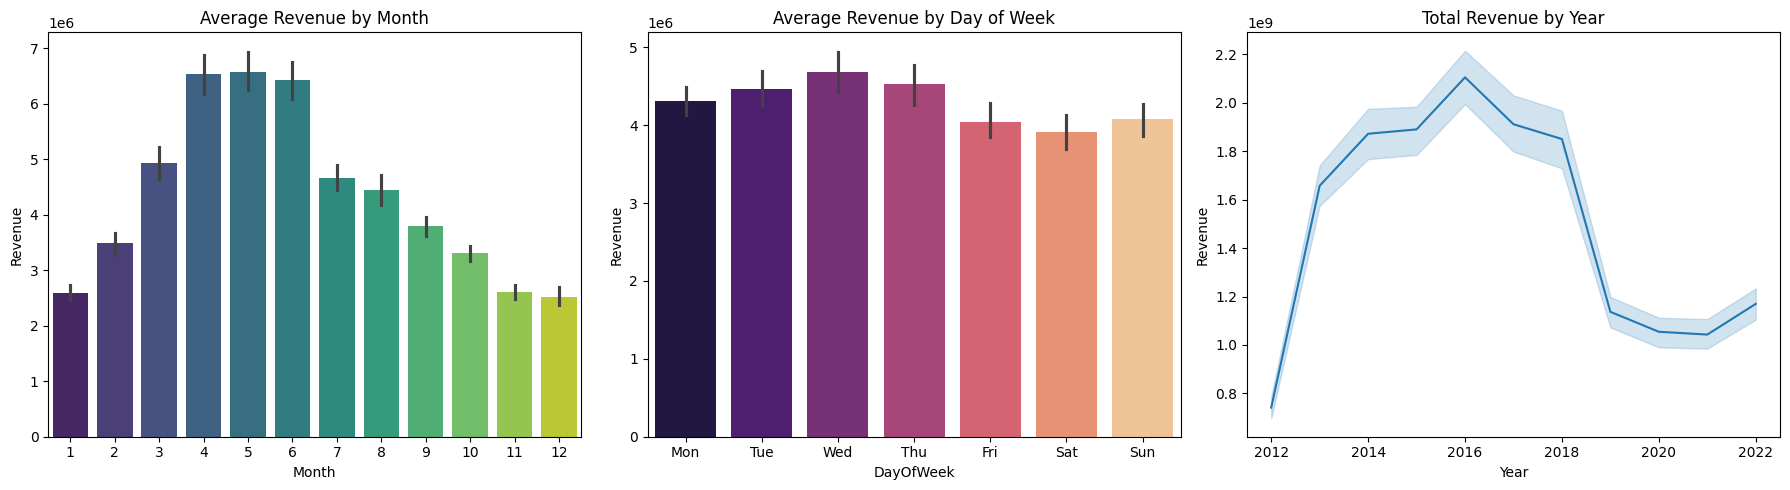

In [28]:
plt.figure(figsize=(18, 5))

# 1. Doanh thu trung bình theo Tháng
plt.subplot(1, 3, 1)
sns.barplot(x='Month', y='Revenue', data=df_copy, palette='viridis')
plt.title('Average Revenue by Month')

# 2. Doanh thu trung bình theo Thứ trong tuần
plt.subplot(1, 3, 2)
sns.barplot(x='DayOfWeek', y='Revenue', data=df_copy, palette='magma')
plt.title('Average Revenue by Day of Week')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# 3. Doanh thu theo Năm
plt.subplot(1, 3, 3)
sns.lineplot(x='Year', y='Revenue', data=df_copy, estimator='sum')
plt.title('Total Revenue by Year')

plt.tight_layout()
plt.show()

**Nhận xét về xu hướng Doanh thu (Revenue)**:

Dựa trên các biểu đồ phân tích, chúng ta có các quan sát chi tiết về biến động doanh thu như sau:

1. Tính mùa vụ (Average Revenue by Month)

* **Đỉnh doanh thu:** Doanh thu trung bình đạt mức cao nhất vào các tháng giữa năm, cụ thể là **tháng 4, 5 và 6**. Đây là giai đoạn thị trường hoạt động sôi nổi nhất.
* **Vùng thấp điểm:** Doanh thu có xu hướng giảm dần về cuối năm và đạt mức thấp nhất vào **tháng 12 và tháng 1**.
* **Xu hướng chung:** Biểu đồ có dạng hình chuông ngược nhẹ, tăng trưởng từ đầu năm, đạt đỉnh vào quý 2 và giảm dần vào hai quý cuối năm.

2. Sự ổn định hàng tuần (Average Revenue by Day of Week)

* **Hiệu suất đầu tuần:** Doanh thu duy trì ở mức cao và ổn định từ Thứ 2 đến Thứ 5, trong đó **Thứ 4 (Wed)** ghi nhận mức doanh thu trung bình cao nhất.
* **Sụt giảm cuối tuần:** Có sự sụt giảm rõ rệt về doanh thu vào các ngày cuối tuần (**Thứ 7 và Chủ Nhật**). Điều này cho thấy khách hàng hoặc các giao dịch có xu hướng tập trung vào các ngày làm việc trong tuần hơn là thời gian nghỉ lễ/cuối tuần.

3. Tăng trưởng dài hạn (Total Revenue by Year)

* **Giai đoạn tăng trưởng (2012 - 2016):** Tổng doanh thu có sự bứt phá mạnh mẽ trong 4 năm đầu và đạt đỉnh lịch sử vào năm **2016** (vượt mốc 2.0 tỷ).
* **Giai đoạn suy thoái (2017 - 2021):** Sau khi đạt đỉnh, doanh thu bắt đầu sụt giảm. Đặc biệt từ sau năm 2018, doanh thu giảm sâu và chạm đáy vào khoảng năm **2020 - 2021** (xuống mức gần 1.0 tỷ).
* **Dấu hiệu phục hồi (2022):** Trong năm gần nhất (2022), biểu đồ đã bắt đầu đảo chiều và có tín hiệu **tăng trưởng trở lại**, cho thấy các nỗ lực phục hồi kinh doanh đang có kết quả khả quan.

Số ngày ghi nhận lỗ gộp: 382
Phần trăm ngày bị lỗ: 9.97%


,Date,Revenue,COGS,Year,Month,DayOfWeek,IsWeekend,GrossProfit
392,2013-07-31,10104475.36,10851542.12,2013,7,2,0,-747066.76
393,2013-08-01,10998208.40,12167214.07,2013,8,3,0,-1169005.67
394,2013-08-02,7422715.15,9601836.11,2013,8,4,0,-2179120.96
395,2013-08-03,5599602.67,7786528.35,2013,8,5,1,-2186925.68
396,2013-08-04,5021938.29,7089757.76,2013,8,6,1,-2067819.47


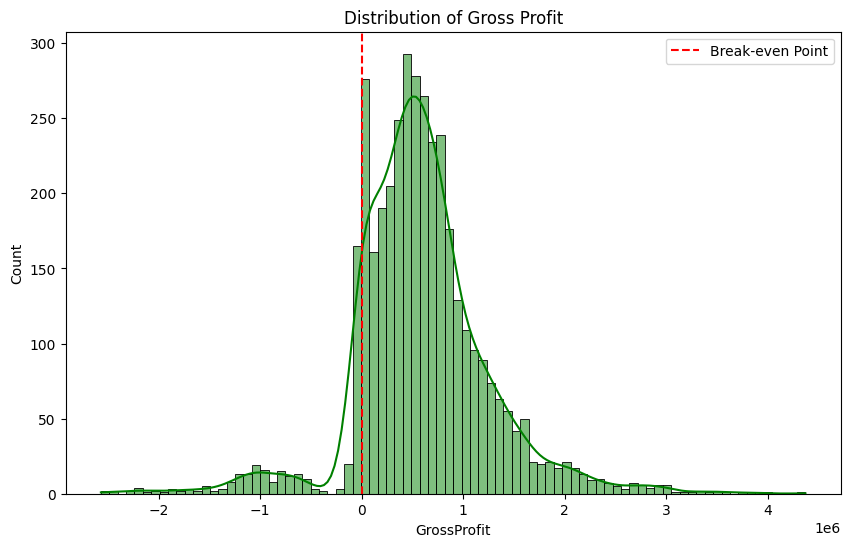

In [29]:
# Tính Gross Profit
df_copy['GrossProfit'] = df_copy['Revenue'] - df_copy['COGS']

# Lọc ra các ngày bị lỗ
loss_days = df_copy[df_copy['GrossProfit'] < 0]

print(f"Số ngày ghi nhận lỗ gộp: {len(loss_days)}")
print(f"Phần trăm ngày bị lỗ: {(len(loss_days)/len(df_copy))*100:.2f}%")

display(loss_days.head())

# Trực quan hóa phân phối Gross Profit
plt.figure(figsize=(10, 6))
sns.histplot(df_copy['GrossProfit'], kde=True, color='green')
plt.axvline(0, color='red', linestyle='--', label='Break-even Point')
plt.title('Distribution of Gross Profit')
plt.legend()
plt.show()

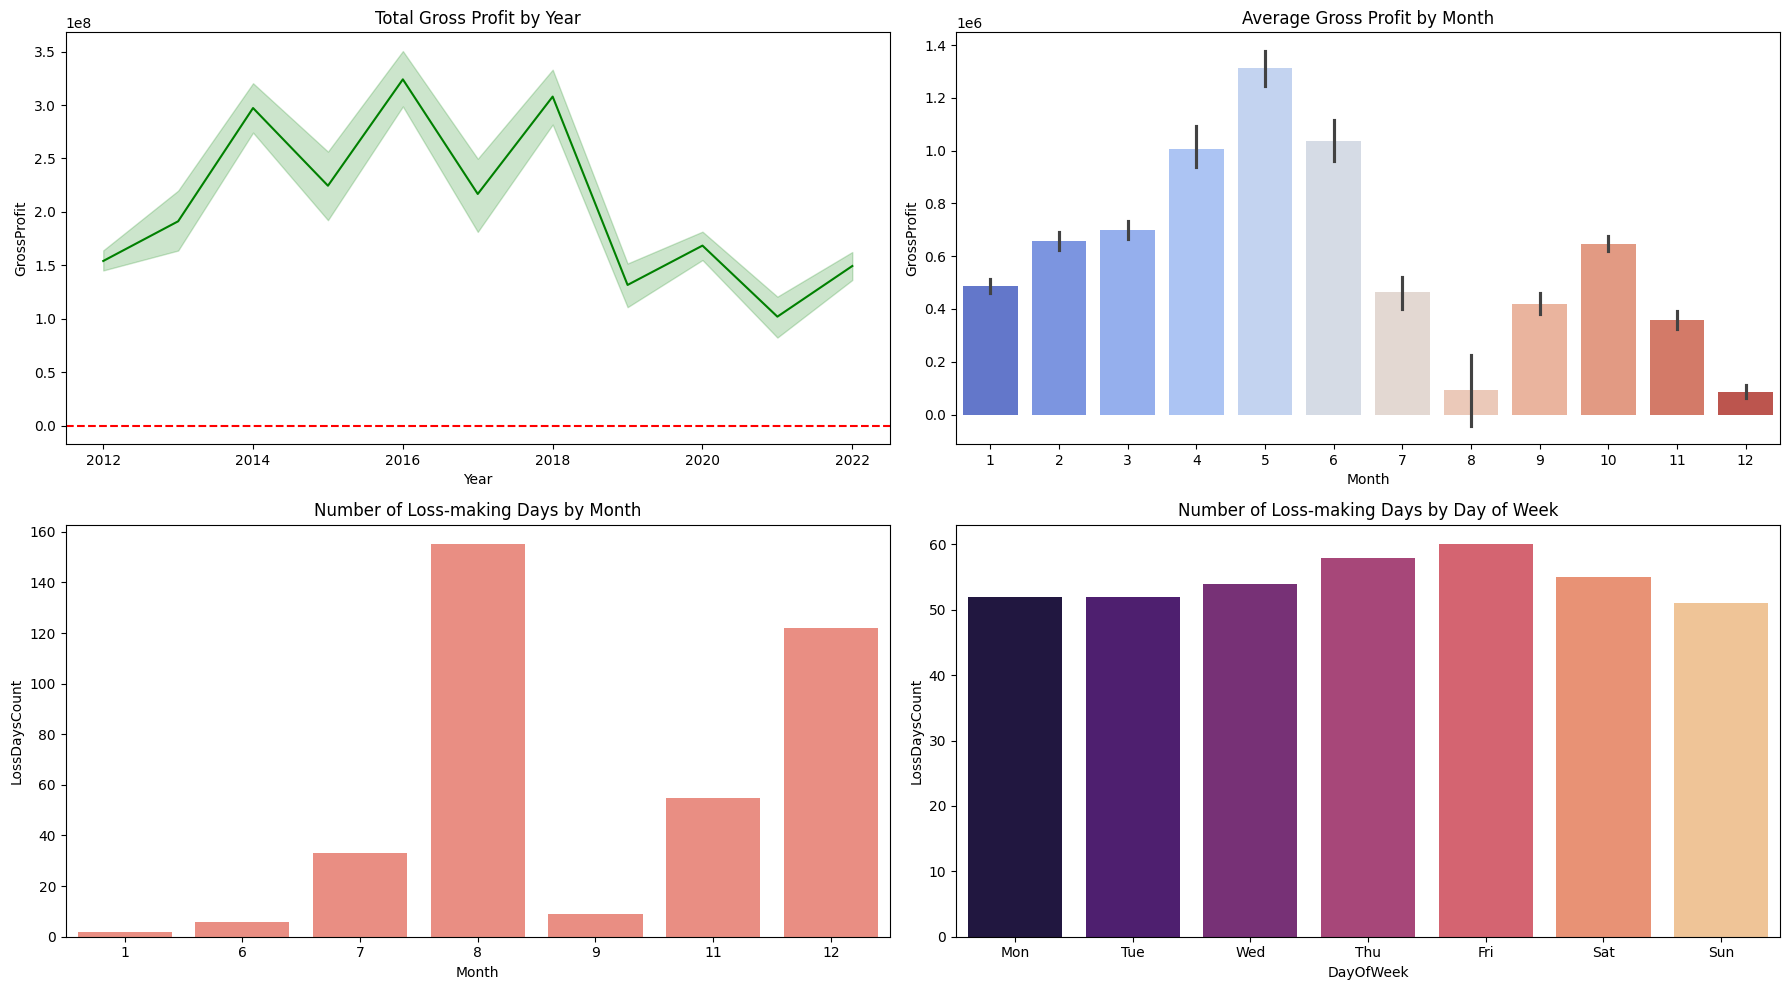

In [30]:
plt.figure(figsize=(18, 10))

# 1. Xu hướng Gross Profit theo thời gian (năm)
plt.subplot(2, 2, 1)
sns.lineplot(x='Year', y='GrossProfit', data=df_copy, estimator='sum', color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Total Gross Profit by Year')

# 2. Gross Profit trung bình theo tháng
plt.subplot(2, 2, 2)
sns.barplot(x='Month', y='GrossProfit', data=df_copy, palette='coolwarm')
plt.title('Average Gross Profit by Month')

# 3. Phân bổ số ngày lỗ theo Tháng
loss_by_month = loss_days.groupby('Month').size().reset_index(name='LossDaysCount')
plt.subplot(2, 2, 3)
sns.barplot(x='Month', y='LossDaysCount', data=loss_by_month, color='salmon')
plt.title('Number of Loss-making Days by Month')

# 4. Phân bổ số ngày lỗ theo Thứ trong tuần
loss_by_dow = loss_days.groupby('DayOfWeek').size().reset_index(name='LossDaysCount')
plt.subplot(2, 2, 4)
sns.barplot(x='DayOfWeek', y='LossDaysCount', data=loss_by_dow, palette='magma')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('Number of Loss-making Days by Day of Week')

plt.tight_layout()
plt.show()

**Nhận xét về Gross Profit theo thời gian:**

- **Biến động theo mùa:** Có sự gia tăng đột biến về số ngày lỗ vào **tháng 8** và **tháng 12**. Điều này có thể liên quan đến các chương trình khuyến mãi lớn hoặc chi phí nhập hàng tăng vọt trong các giai đoạn này.
- **Tính ổn định:** Gross Profit theo năm không ổn định, cần kiểm tra xem doanh thu giảm hay COGS tăng trong các giai đoạn lợi nhuận thấp.
- **Ngày trong tuần:** Không có sự khác biệt quá lớn về rủi ro lỗ giữa các ngày trong tuần.

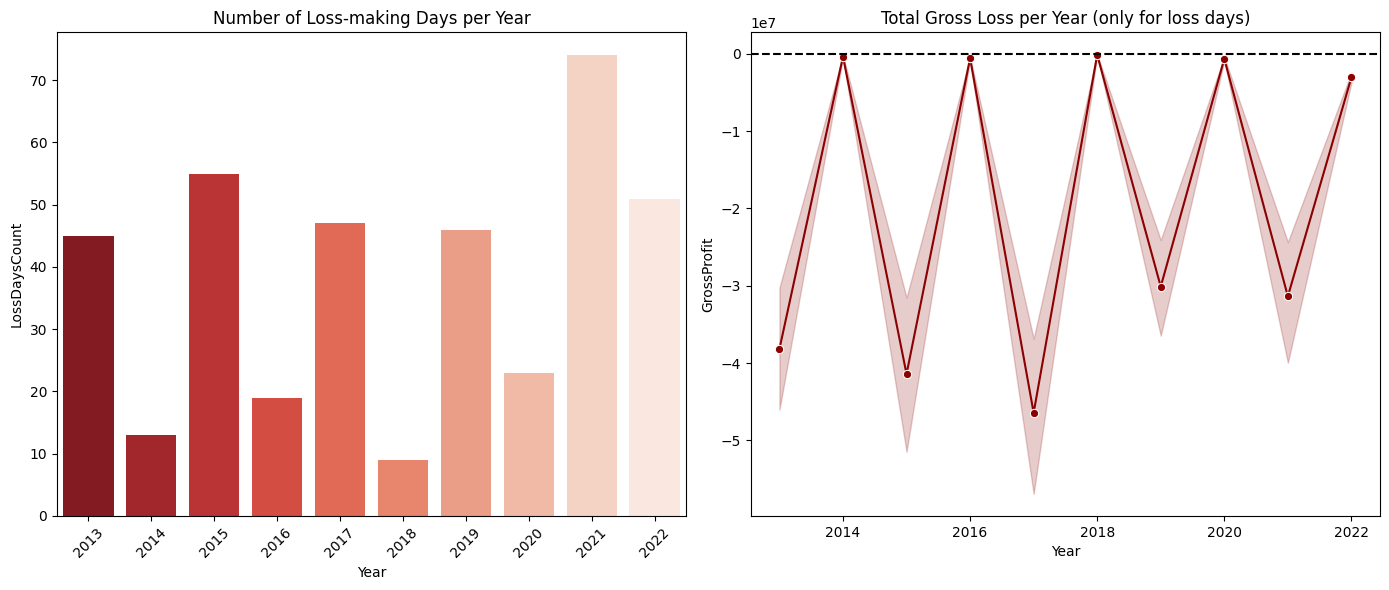

Thống kê số ngày lỗ cụ thể qua từng năm:


,Year,LossDaysCount
0,2013,45
1,2014,13
2,2015,55
3,2016,19
4,2017,47
5,2018,9
6,2019,46
7,2020,23
8,2021,74
9,2022,51


In [31]:
# Thống kê số ngày lỗ theo Năm
loss_by_year = loss_days.groupby('Year').size().reset_index(name='LossDaysCount')

# Vẽ biểu đồ
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Year', y='LossDaysCount', data=loss_by_year, palette='Reds_r')
plt.title('Number of Loss-making Days per Year')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GrossProfit', data=loss_days, estimator='sum', marker='o', color='darkred')
plt.title('Total Gross Loss per Year (only for loss days)')
plt.axhline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

# Hiển thị bảng dữ liệu để soi chi tiết
print("Thống kê số ngày lỗ cụ thể qua từng năm:")
display(loss_by_year.sort_values('Year'))

Thống kê này giúp làm rõ hơn vấn đề 382 ngày lỗ mà chúng ta thấy ở phần EDA. Những ngày lỗ này không rải đều mà biến động theo chu kỳ và chịu ảnh hưởng nặng nề bởi các yếu tố vĩ mô (điển hình là 2021). Trong quá trình xây dựng mô hình dự báo (Forecasting) tiếp theo, bạn có thể cân nhắc tạo thêm các biến giả (dummy variables) cho năm 2021 hoặc các cờ báo hiệu (flags) cho chu kỳ xả hàng/thanh lý để mô hình học được quy luật zíc-zắc này.

In [32]:
# Xóa các cột đặc trưng thời gian vừa tạo
df_copy = df_copy.drop(columns=['Year', 'Month', 'DayOfWeek', 'IsWeekend', 'GrossProfit'])

print("Đã xóa các cột Year, Month, DayOfWeek, IsWeekend.")
display(df_copy.head())

Đã xóa các cột Year, Month, DayOfWeek, IsWeekend.


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [33]:
# Lưu file vào thư mục trên Google Drive
drive_output_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/sales_cleaned.csv'
df_copy.to_csv(drive_output_path, index=False)

print(f"Đã lưu file vào Drive thành công: {drive_output_path}")